Going to use a simple "toy" function

f(x,y) = (x-2)^2-xy+(y-3)^2

Text(0.5, 0.5, 'Y')

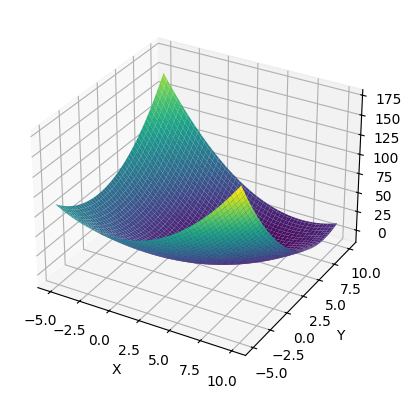

In [1]:
#Import packages for visualization
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#define the height of the terrain
def f(coordinates):
  x, y = coordinates
  return (x-2)**2 - x*y + (y-3)**2

#Visualization
x_range = np.linspace(-5, 10, 100)
y_range = np.linspace(-5, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f([X, Y])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')

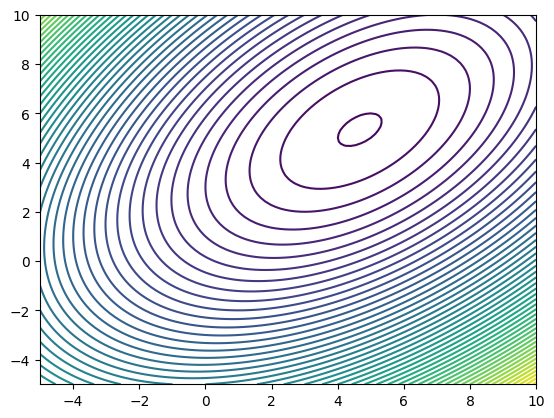

In [2]:
#different visualization
plt.contour(X, Y, Z, levels=50, cmap='viridis')
plt.show()
#This is useful b/c the center of the "bulls-eye" is going to be a max or min
#Where the rings are closer together represents steepness

Methods for finding the minima:
 - Guess and check ----- Probably bad
 - Nelder-Mead ----- To optimize a surface the Nelder-Mead method uses a moving geometric figure called a simplex (a triangle in 2d). The algorithm evaluates the function at 3 vertices, ranking them from best to worst. It systematically updates
 - Gradient Descent ----- On a 2d surface use the gradient to find the steepest ascent. To find a minima use the negetive gradient direction.
 - Newton's Method ----- Use both slope and concavity,

In [3]:
#Nelder-Mead

#Initial Guess (starting simplex vertex)
x0 = np.array([0.0, 0.0])

#Execute Nelder-Mead optimization
res = minimize(f, x0, method='Nelder-Mead', options={'xatol': 1e-8, 'disp': True})

#Print the results
print(res)

Optimization terminated successfully.
         Current function value: -12.333333
         Iterations: 104
         Function evaluations: 206
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -12.333333333333336
             x: [ 4.667e+00  5.333e+00]
           nit: 104
          nfev: 206
 final_simplex: (array([[ 4.667e+00,  5.333e+00],
                       [ 4.667e+00,  5.333e+00],
                       [ 4.667e+00,  5.333e+00]]), array([-1.233e+01, -1.233e+01, -1.233e+01]))


Final Point: [4.6408978  5.30756445]
Minimum: -12.332669298361143


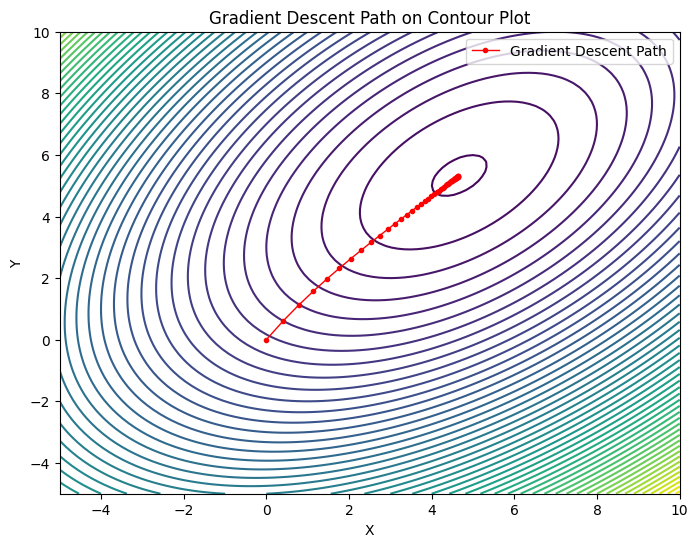

In [4]:
#Gradient Descent

#define the equation for the gradient using partial derivatives
def grad_f(v):
  x, y = v[0], v[1]
  dx = 2*x - y - 4
  dy = -x + 2*y - 6
  return np.array([dx, dy])

#Parameters
v = np.array([0.0, 0.0])  # Initial guess
alpha = 0.1              # Learning rate
epochs = 50              # Iterations ----- Had to add more to get an accurate result

# To store the path for visualization
path = []
path.append(v.copy())

# 2D Gradient Descent Loop
for epoch in range(epochs):
    grad = grad_f(v)
    v = v - alpha * grad
    path.append(v.copy())

print("Final Point:", v)
print("Minimum:", f(v))

#Graph the gradient gradient map produced by this method:

# Convert path to numpy array for easier plotting
path = np.array(path)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=50, cmap='viridis')
plt.plot(path[:, 0], path[:, 1], 'r-o', markersize=3, linewidth=1, label='Gradient Descent Path')
plt.title('Gradient Descent Path on Contour Plot')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [5]:
#Newtons Method for 2D surfaces --- This method is really good


# Define Gradient & Hessian
def grad(xy):
  x, y = xy[0], xy[1]
  return np.array([2*(x-2) - y, -x + 2*(y-3)])



def hessian(xy):
  return np.array([[2.0, -1.0], [-1.0, 2.0]])



# Iteration Step
xy = np.array([0.0, 0.0])
for _ in range(5):
  g = grad(xy)
  H = hessian(xy)
  xy = xy - np.linalg.solve(H, g)
  print(f"interation {_+1} xy: {xy}")


print(f"\nFinal xy after Newton's method: {xy}")
print(f"Minimum value: {f(xy)}")

interation 1 xy: [4.66666667 5.33333333]
interation 2 xy: [4.66666667 5.33333333]
interation 3 xy: [4.66666667 5.33333333]
interation 4 xy: [4.66666667 5.33333333]
interation 5 xy: [4.66666667 5.33333333]

Final xy after Newton's method: [4.66666667 5.33333333]
Minimum value: -12.333333333333336
